In [1]:
import joblib              as jlb
import matplotlib.pyplot   as plt
import warnings
warnings.filterwarnings('ignore')
    
from collections           import Counter
from Algorithm             import PAM
from pyclustering.utils import timedcall
from Dataprepare.data_processing import D,data_pca
from utils.Pam_fast_build import PAM_silhouette_analysis,PAM_davies_bouldin_analysis,PAM_Inertia_analysis

Tiền xử lý dữ liệu

In [2]:
features=[
 'balance',
 'purchases',
 'cash_advance'
]
data=D[features].copy()
print(data.shape)
print(data.head(2))

(1898, 3)
    balance  purchases  cash_advance
0 -1.594479  -0.275098     -0.926725
1  0.746068  -1.836079      1.487937


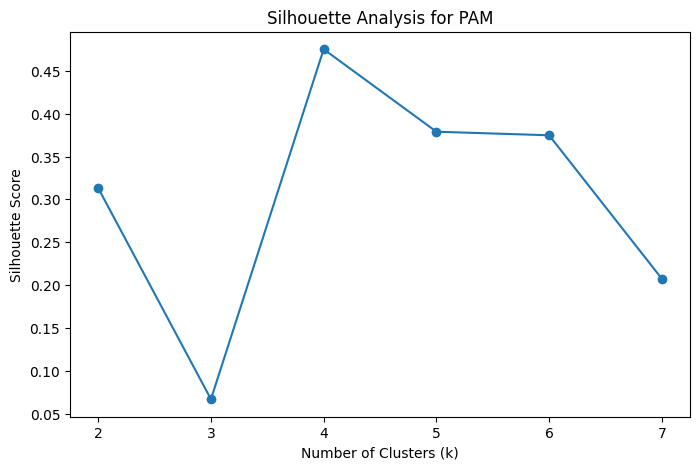

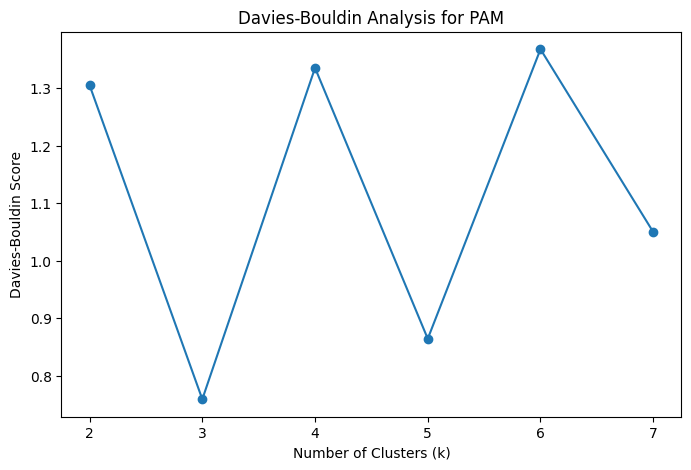

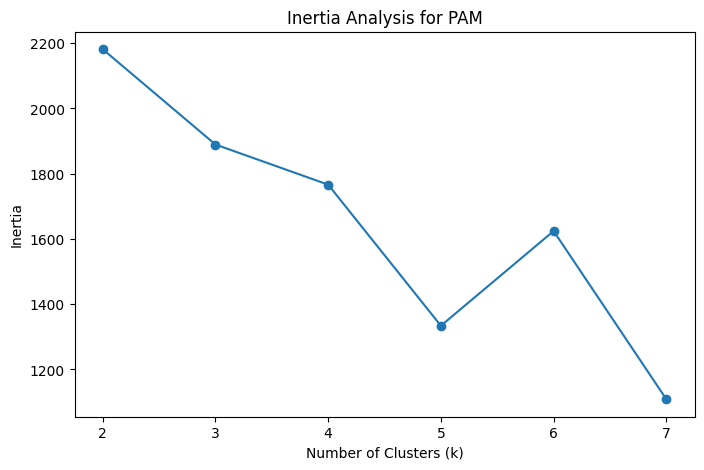

In [3]:
PAM_silhouette_analysis(data, range(2, 8))
PAM_davies_bouldin_analysis(data, range(2, 8))
PAM_Inertia_analysis(data, range(2, 8))

Xây dựng mô hình PAM

In [4]:
k=4
Pam_model=PAM(data,n_clusters = k)
(ticks,results) = timedcall(Pam_model.fit)
print(f'PAM clustering completed in {ticks:.4f} seconds.')

PAM clustering completed in 0.0668 seconds.


In [5]:
## Lưu trữ mô hình để khai thác về sau
jlb.dump(Pam_model, '../customer_clustering/Output/PAM.mdl')

['../customer_clustering/Output/PAM.mdl']

In [6]:
## Khai thác mô hình đã được xây dựng
saved=jlb.load('../customer_clustering/Output/PAM.mdl')

In [7]:
## Kết quả gom cụm khách hàng
data['cluster'] = saved.get_labels()

print('\nKích thước các clusters:', Counter(data['cluster']))
print('\n2 clusters lớn nhất:',    Counter(data['cluster']).most_common(2))


Kích thước các clusters: Counter({3: 723, 0: 634, 1: 370, 2: 171})

2 clusters lớn nhất: [(3, 723), (0, 634)]


In [9]:
medoids = saved.get_medoids()
labels= saved.get_labels()
print(labels)
print(medoids)

[0 3 1 ... 3 2 3]
[[-1.0336541   0.37947025 -0.92672452]
 [ 0.53214786  0.69092857 -0.92672452]
 [ 0.93565167  0.7770384   1.21524415]
 [ 0.56062757 -0.71944254  0.75749196]]


Biểu diễn trực quan

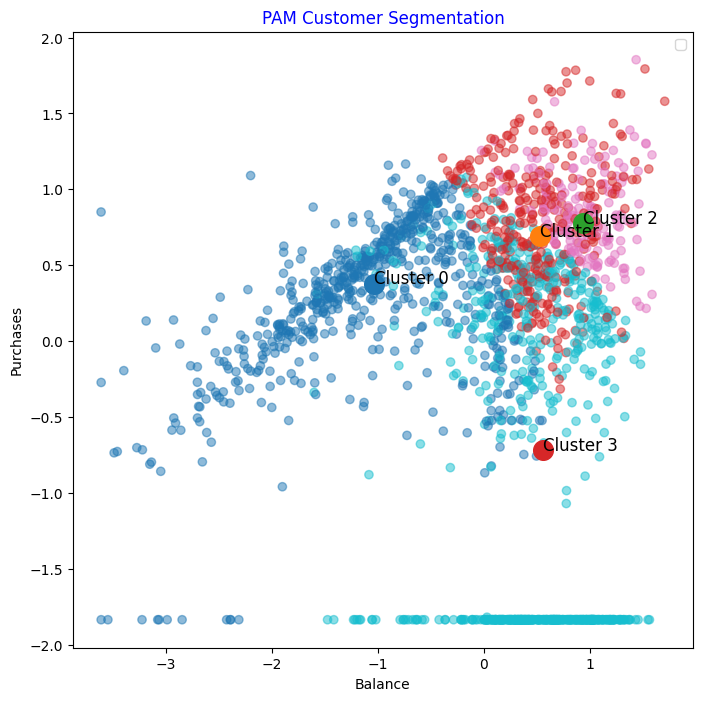

In [10]:
plt.figure(figsize = (8, 8))
plt.scatter(data['balance'], data['purchases'], c = labels, alpha = 0.5, cmap = 'tab10')
for i, medoid in enumerate(medoids):
    plt.scatter(medoid[0], medoid[1], s=200, marker='o')

    plt.text(
        medoid[0],
        medoid[1],
        f'Cluster {i}',
        fontsize=12
    )
plt.xlabel('Balance')
plt.ylabel('Purchases')
plt.title('PAM Customer Segmentation', color = 'blue')
plt.legend()
plt.show()

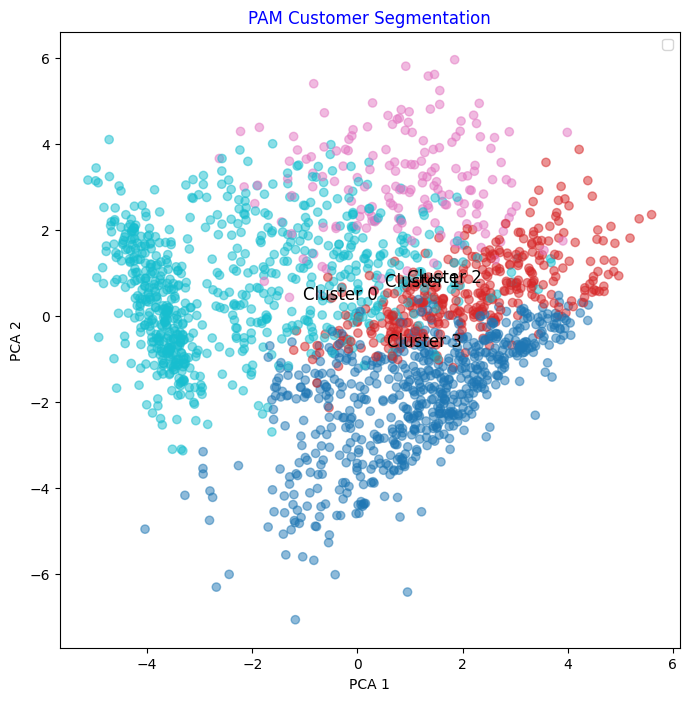

In [11]:
plt.figure(figsize = (8, 8))
plt.scatter(data_pca[:, 0], data_pca[:, 1], c = labels, alpha = 0.5, cmap = 'tab10')
for i, medoid in enumerate(medoids):

    plt.text(
        medoid[0],
        medoid[1],
        f'Cluster {i}',
        fontsize=12
    )
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.title('PAM Customer Segmentation', color = 'blue')
plt.legend()
plt.show()